In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU

In [2]:
start='2015-01-01'
end='2025-12-31'
stock='GOOG'

data=yf.download(stock,start,end)

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
2015-01-02,25.955561,26.275055,25.920447,26.163280,28951268
2015-01-05,25.414501,25.931822,25.374442,25.878903,41196796
2015-01-06,24.825468,25.528501,24.780464,25.470389,57998800
2015-01-07,24.782934,25.086798,24.711221,25.074730,41301082
2015-01-08,24.861074,24.900640,24.283416,24.629121,67071641


In [4]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [f"{col[0]} {col[1]}" for col in data.columns]

In [5]:
data.rename(columns={
    "Price Ticker":"Date",
    "Close GOOG":"Close",
    "High GOOG":"High",
    "Low GOOG":"Low",
    "Open GOOG":"Open",
    "Volume GOOG":"Volume"
},inplace=True)

In [6]:
data.index.name = "Date"
data.reset_index(inplace=True)

In [7]:
data.sample(5)

,Date,Close,High,Low,Open,Volume
2448,2024-09-25,162.059769,163.279756,161.845984,162.039879,13607900
2467,2024-10-22,165.867920,166.514204,163.730181,163.760009,11958600
2506,2024-12-17,196.217331,201.950964,195.789307,197.620878,24129500
345,2016-05-17,35.023956,35.782231,34.918820,35.507981,40024000
887,2018-07-12,58.692139,58.738261,57.326103,57.522243,25038000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2765 non-null   datetime64[s]
 1   Close   2765 non-null   float64      
 2   High    2765 non-null   float64      
 3   Low     2765 non-null   float64      
 4   Open    2765 non-null   float64      
 5   Volume  2765 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 129.7 KB


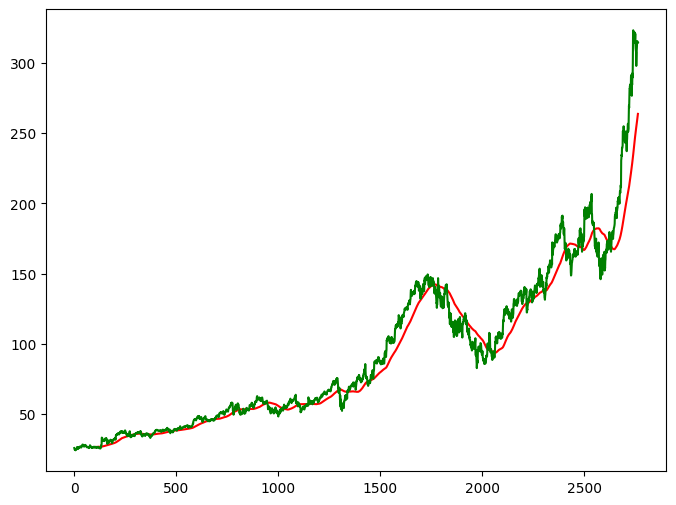

In [9]:
ma_100_days=data['Close'].rolling(100).mean()

plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(data['Close'],'g')

plt.show()

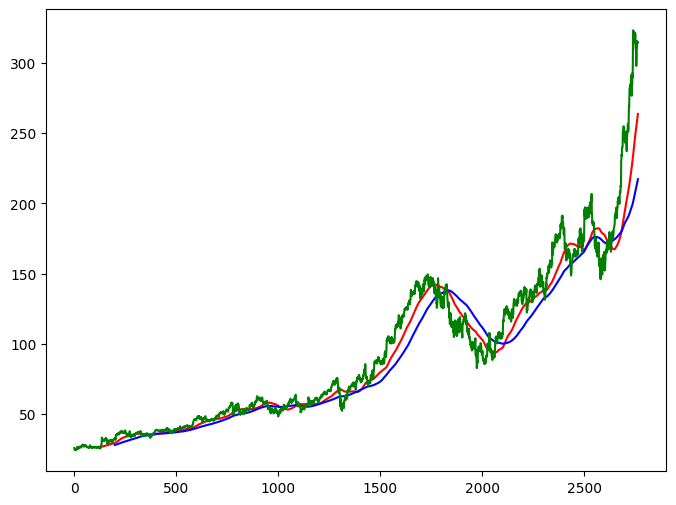

In [10]:
ma_200_days=data['Close'].rolling(200).mean()

plt.figure(figsize=(8,6))
plt.plot(ma_100_days,'r')
plt.plot(ma_200_days,'b')
plt.plot(data['Close'],'g')

plt.show()

.pct_change() calculates the relative change from the previous row automatically. Under the hood, for any given day $t$, it calculates:$$\text{Percentage Change}_t = \frac{\text{Price}_t - \text{Price}_{t-1}}{\text{Price}_{t-1}}$$Since the very first day ($t=0$) does not have a previous day ($t=-1$), its calculated value will be NaN (Not a Number), which we must drop immediately using .dropna()

In [11]:
data['Close_Pct'] = data['Close'].pct_change()

In [12]:
features = ['Close_Pct', 'Volume','Close']
data_filtered = data[features].copy()

In [13]:
data_filtered.dropna(inplace=True)

In [14]:
data_filtered.head()

,Close_Pct,Volume,Close
1,-0.020846,41196796,25.414501
2,-0.023177,57998800,24.825468
3,-0.001713,41301082,24.782934
4,0.003153,67071641,24.861074
5,-0.012950,41427428,24.539114


In [15]:
data_train = data_filtered.iloc[0:int(len(data_filtered) * 0.80)].copy()
data_test = data_filtered.iloc[int(len(data_filtered) * 0.80):].copy()

print(f"\nTraining set size: {data_train.shape[0]} rows")
print(f"Testing set size: {data_test.shape[0]} rows")


Training set size: 2211 rows
Testing set size: 553 rows


In [16]:
scaler_pct = MinMaxScaler()
scaler_vol = MinMaxScaler()

train_pct_scaled = scaler_pct.fit_transform(data_train[['Close_Pct']])
train_vol_scaled = scaler_vol.fit_transform(data_train[['Volume']])

data_train_scaled = np.hstack((train_pct_scaled, train_vol_scaled))

In [17]:
x_train = []
y_train = []

for i in range(99, data_train_scaled.shape[0]):
    x_train.append(data_train_scaled[i-99:i])
    y_train.append(data_train_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f"\nShape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of x_train: (2112, 99, 2)
Shape of y_train: (2112,)


In [18]:
model_lstm = Sequential()

model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=80, return_sequences=True))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=100, return_sequences=True))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=120))  
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(units=1))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(x_train, y_train, epochs=60, batch_size=32, verbose=1)

Epoch 1/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0130
Epoch 2/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0053
Epoch 3/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0056
Epoch 4/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0054
Epoch 5/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0053
Epoch 6/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0051
Epoch 7/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0053
Epoch 8/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0051
Epoch 9/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0053
Epoch 10/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0052
Epoch 11/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0050
Epoch 12/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0050
Epoch 13/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0054
Epoch 14/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0051
Epoch 15/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0050
Epoc

In [20]:
model_gru = Sequential()

model_gru.add(GRU(units=60, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model_gru.add(Dropout(0.2))

model_gru.add(GRU(units=80, return_sequences=True))
model_gru.add(Dropout(0.2))

model_gru.add(GRU(units=100, return_sequences=True))
model_gru.add(Dropout(0.2))

model_gru.add(GRU(units=120))
model_gru.add(Dropout(0.2))

model_gru.add(Dense(units=1))

In [21]:
model_gru.compile(optimizer='adam', loss='mean_squared_error')
model_gru.fit(x_train, y_train, epochs=60, batch_size=32, verbose=1)

Epoch 1/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 0.0124
Epoch 2/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0056
Epoch 3/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0056
Epoch 4/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0054
Epoch 5/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0053
Epoch 6/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0052
Epoch 7/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0052
Epoch 8/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0051
Epoch 9/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0051
Epoch 10/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0050
Epoch 11/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0051
Epoch 12/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0051
Epoch 13/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0050
Epoch 14/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0049
Epoch 15/60
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0051
Epoc

In [22]:
past_99_days = data_train.tail(99)
data_test_full = pd.concat((past_99_days, data_test), ignore_index=True)

test_pct_scaled = scaler_pct.transform(data_test_full[['Close_Pct']])
test_vol_scaled = scaler_vol.transform(data_test_full[['Volume']])

In [23]:
data_test_scaled = np.hstack((test_pct_scaled, test_vol_scaled))

x_test = []
for i in range(99, data_test_scaled.shape[0]):
    x_test.append(data_test_scaled[i-99:i])

x_test = np.array(x_test)

In [24]:
y_pred_lstm_scaled = model_lstm.predict(x_test)
y_pred_gru_scaled = model_gru.predict(x_test)

pred_pct_lstm = scaler_pct.inverse_transform(y_pred_lstm_scaled).flatten()
pred_pct_gru = scaler_pct.inverse_transform(y_pred_gru_scaled).flatten()

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [25]:
actual_prices = data_test['Close'].values

In [26]:
predicted_price_lstm = []
predicted_price_gru = []

for i in range(len(actual_prices)):
    if i == 0:
        prev_price = data_train['Close'].iloc[-1]
    else:
        prev_price = actual_prices[i-1]
    predicted_price_lstm.append(prev_price * (1 + pred_pct_lstm[i]))
    predicted_price_gru.append(prev_price * (1 + pred_pct_gru[i]))

predicted_price_lstm = np.array(predicted_price_lstm)
predicted_price_gru = np.array(predicted_price_gru)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models_advanced(y_true, pred_m1, pred_m2):

    y_true = np.asarray(y_true).flatten()
    pred_m1 = np.asarray(pred_m1).flatten()
    pred_m2 = np.asarray(pred_m2).flatten()

    actual_dir = np.sign(y_true[1:] - y_true[:-1])

    dir_m1 = np.sign(pred_m1[1:] - y_true[:-1])
    dir_m2 = np.sign(pred_m2[1:] - y_true[:-1])

    mask = actual_dir != 0

    actual_dir = actual_dir[mask]
    dir_m1 = dir_m1[mask]
    dir_m2 = dir_m2[mask]

    mda_m1 = np.mean(actual_dir == dir_m1) * 100
    mda_m2 = np.mean(actual_dir == dir_m2) * 100

    def directional_stats(actual, pred, cls):
        tp = np.sum((pred == cls) & (actual == cls))
        fp = np.sum((pred == cls) & (actual != cls))
        fn = np.sum((pred != cls) & (actual == cls))
        precision = 100 * tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = 100 * tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )
        return precision, recall, f1

    statistical_metrics = {
        "Metric": [
            "MAE",
            "RMSE",
            "R² Score"
        ],
        "Model 1 (LSTM)": [
            f"{mean_absolute_error(y_true,pred_m1):.4f}",
            f"{np.sqrt(mean_squared_error(y_true,pred_m1)):.4f}",
            f"{r2_score(y_true,pred_m1):.4f}"
        ],
        "Model 2 (GRU)": [
            f"{mean_absolute_error(y_true,pred_m2):.4f}",
            f"{np.sqrt(mean_squared_error(y_true,pred_m2)):.4f}",
            f"{r2_score(y_true,pred_m2):.4f}"
        ]
    }

    directional_metrics = {
        "Metric": [
            "Directional Accuracy (MDA)",
        ],
        "Model 1 (LSTM)": [
            f"{mda_m1:.2f}%"
        ],
        "Model 2 (GRU)": [
            f"{mda_m2:.2f}%"
        ]
    }

    df1 = pd.DataFrame(statistical_metrics)
    df2 = pd.DataFrame(directional_metrics)

    return pd.concat([df1, df2], ignore_index=True)
metrics_summary = evaluate_models_advanced(actual_prices, predicted_price_lstm, predicted_price_gru)
metrics_summary

,Metric,Model 1 (LSTM),Model 2 (GRU)
0,MAE,2.4430,2.4410
1,RMSE,3.4974,3.5134
2,R² Score,0.9939,0.9939
3,Directional Accuracy (MDA),56.70%,56.70%


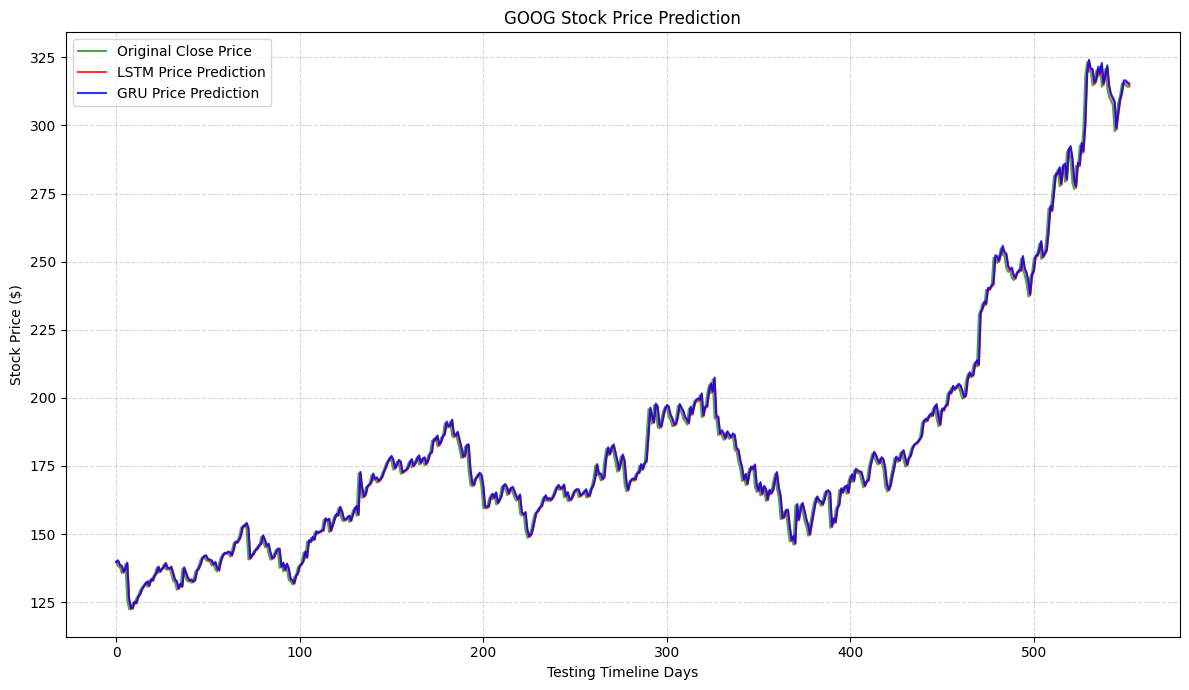

In [44]:
plt.figure(figsize=(12, 7))
plt.plot(actual_prices, color='green', label='Original Close Price', alpha=0.7)
plt.plot(predicted_price_lstm, color='red', label='LSTM Price Prediction', alpha=0.8)
plt.plot(predicted_price_gru, color='blue', label='GRU Price Prediction', alpha=0.8)

plt.title('GOOG Stock Price Prediction')
plt.xlabel('Testing Timeline Days')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [48]:
model_lstm.save('Prediction model(LSTM).keras')
model_gru.save('Prediction model(GRU).keras')